In [1]:
from pathlib import Path
from tqdm import tqdm

import pandas as pd
import rasterio

from rasterio.warp import transform_bounds

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

RGB_DIR = DATA_DIR / "eurosat" / "EuroSAT"
MS_DIR = DATA_DIR / "eurosat" / "EuroSATallBands"

PROCESSED_DIR = DATA_DIR / "processed"

print("RGB:", RGB_DIR)
print("MS :", MS_DIR)

RGB: c:\Users\ASUS\dev\projects\satellite-project\data\eurosat\EuroSAT
MS : c:\Users\ASUS\dev\projects\satellite-project\data\eurosat\EuroSATallBands


In [3]:
print("RGB Exists:", RGB_DIR.exists())
print("MS Exists :", MS_DIR.exists())

rgb_classes = sorted(
    [
        folder.name
        for folder in RGB_DIR.iterdir()
        if folder.is_dir()
    ]
)

print("\nClasses:")
for cls in rgb_classes:
    print(cls)

RGB Exists: True
MS Exists : True

Classes:
AnnualCrop
Forest
HerbaceousVegetation
Highway
Industrial
Pasture
PermanentCrop
Residential
River
SeaLake


In [4]:
ms_files = list(
    MS_DIR.rglob("*.tif")
)

print("Total TIFF Files:", len(ms_files))

Total TIFF Files: 27597


In [5]:
sample_file = ms_files[0]

print(sample_file)

c:\Users\ASUS\dev\projects\satellite-project\data\eurosat\EuroSATallBands\AnnualCrop\AnnualCrop_1.tif


In [6]:
with rasterio.open(sample_file) as src:

    print("CRS:", src.crs)
    print("Bands:", src.count)

    bounds = transform_bounds(
        src.crs,
        "EPSG:4326",
        *src.bounds
    )

    print("\nWGS84 Bounds:")
    print(bounds)

CRS: EPSG:32635
Bands: 13

WGS84 Bounds:
(28.554985107858464, 44.03228720566504, 28.563125021528563, 44.0381529100318)


In [7]:
def extract_geospatial_metadata(tif_path):

    with rasterio.open(tif_path) as src:

        bounds = transform_bounds(
            src.crs,
            "EPSG:4326",
            *src.bounds
        )

        min_lon, min_lat, max_lon, max_lat = bounds

        center_lon = (min_lon + max_lon) / 2
        center_lat = (min_lat + max_lat) / 2

        return {
            "center_lat": center_lat,
            "center_lon": center_lon
        }

In [8]:
records = []

for tif_path in tqdm(ms_files):

    relative_path = tif_path.relative_to(MS_DIR)

    class_name = relative_path.parts[0]

    base_name = tif_path.stem

    rgb_path = (
        RGB_DIR
        / class_name
        / f"{base_name}.jpg"
    )

    geo = extract_geospatial_metadata(tif_path)

    records.append(
        {
            "filepath_rgb": str(rgb_path),
            "filepath_tif": str(tif_path),
            "class_name": class_name,
            "center_lat": geo["center_lat"],
            "center_lon": geo["center_lon"]
        }
    )

100%|██████████| 27597/27597 [01:52<00:00, 245.85it/s]


In [9]:
metadata_df = pd.DataFrame(records)

print(metadata_df.shape)

metadata_df.head()

(27597, 5)


,filepath_rgb,filepath_tif,class_name,center_lat,center_lon
0,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,44.035220,28.559055
1,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,39.085801,-1.829726
2,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,48.977295,4.239720
3,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,48.892610,4.089878
4,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,51.832851,18.084960


In [10]:
print("Missing RGB Paths:",
      metadata_df["filepath_rgb"].isna().sum())

print("Missing Latitudes:",
      metadata_df["center_lat"].isna().sum())

print("Missing Longitudes:",
      metadata_df["center_lon"].isna().sum())

Missing RGB Paths: 0
Missing Latitudes: 0
Missing Longitudes: 0


In [11]:
metadata_df[
    [
        "center_lat",
        "center_lon"
    ]
].describe()

,center_lat,center_lon
count,27597.000000,27597.000000
mean,47.098877,10.977196
std,9.432909,16.719916
min,-5.428416,-20.993892
25%,43.596446,1.855008
50%,48.727699,8.299807
75%,52.182263,16.697739
max,65.237817,106.807624


In [12]:
metadata_df["class_name"].value_counts()

class_name
SeaLake                 3597
AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    3000
Residential             3000
Highway                 2500
PermanentCrop           2500
Industrial              2500
River                   2500
Pasture                 2000
Name: count, dtype: int64

In [13]:
metadata_path = (
    PROCESSED_DIR
    / "eurosat_spatial_metadata.csv"
)

metadata_df.to_csv(
    metadata_path,
    index=False
)

print(metadata_path)

c:\Users\ASUS\dev\projects\satellite-project\data\processed\eurosat_spatial_metadata.csv


In [14]:
loaded_df = pd.read_csv(metadata_path)

print(loaded_df.shape)

loaded_df.head()

(27597, 5)


,filepath_rgb,filepath_tif,class_name,center_lat,center_lon
0,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,44.035220,28.559055
1,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,39.085801,-1.829726
2,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,48.977295,4.239720
3,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,48.892610,4.089878
4,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,51.832851,18.084960


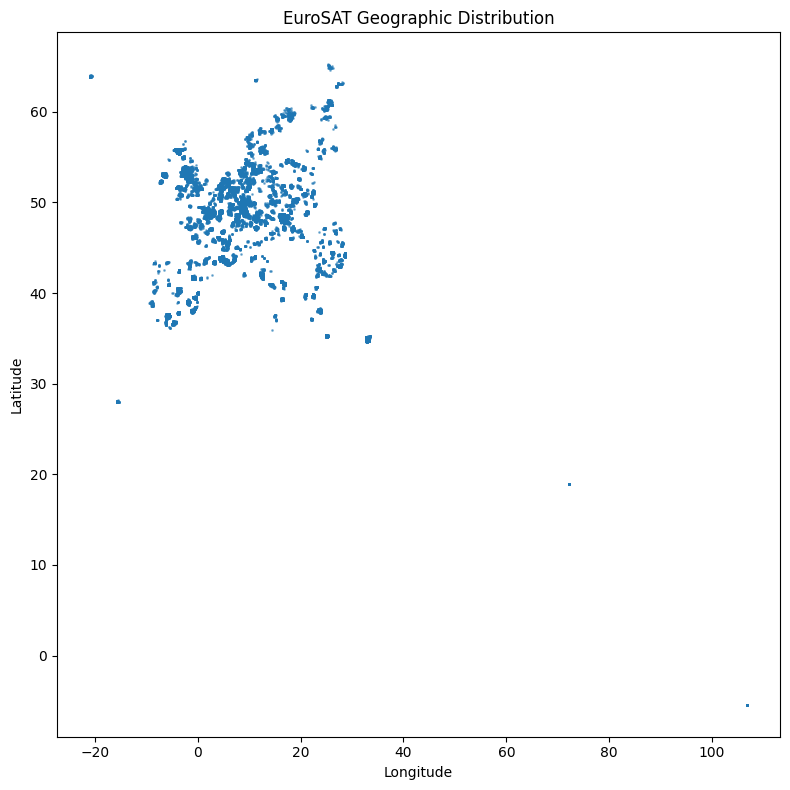

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.scatter(
    metadata_df["center_lon"],
    metadata_df["center_lat"],
    s=1,
    alpha=0.5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("EuroSAT Geographic Distribution")

plt.tight_layout()
plt.show()

In [16]:
rgb_count = len(list(RGB_DIR.rglob("*.jpg")))
ms_count = len(list(MS_DIR.rglob("*.tif")))

print("RGB:", rgb_count)
print("MS :", ms_count)

RGB: 27000
MS : 27597


In [17]:
for cls in sorted(rgb_classes):
    rgb_n = len(list((RGB_DIR / cls).glob("*.jpg")))
    ms_n = len(list((MS_DIR / cls).glob("*.tif")))

    print(f"{cls:25s} RGB={rgb_n:5d} MS={ms_n:5d}")

AnnualCrop                RGB= 3000 MS= 3000
Forest                    RGB= 3000 MS= 3000
HerbaceousVegetation      RGB= 3000 MS= 3000
Highway                   RGB= 2500 MS= 2500
Industrial                RGB= 2500 MS= 2500
Pasture                   RGB= 2000 MS= 2000
PermanentCrop             RGB= 2500 MS= 2500
Residential               RGB= 3000 MS= 3000
River                     RGB= 2500 MS= 2500
SeaLake                   RGB= 3000 MS= 3597
